# Learning Rate Scheduler

learning rate scheduler는 학습 중 learning rate를 자동으로 조절하는 도구이다.

- learning rate가 너무 크면 학습이 흔들릴 수 있다.
- learning rate가 너무 작으면 학습이 느릴 수 있다.
- 그래서 학습 중간에 learning rate를 조절하는 scheduler를 함께 사용하는 경우가 많다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.set_num_threads(1)
torch.manual_seed(42)
np.random.seed(42)

## 1. 데이터 준비

In [2]:
# 데이터 생성
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

# train / validation 분리
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 입력값 스케일 정리
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# tensor 변환
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_val = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


## 2. 모델 및 평가 함수 준비

In [3]:
class BinaryMLP(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.net(x)

In [4]:
def evaluate_binary_model(model, X_train, y_train, X_val, y_val):
    criterion = nn.BCEWithLogitsLoss()

    model.eval()
    with torch.no_grad():
        train_logits = model(X_train)
        val_logits = model(X_val)

        train_loss = criterion(train_logits, y_train).item()
        val_loss = criterion(val_logits, y_val).item()

        train_pred = (torch.sigmoid(train_logits) >= 0.5).float()
        val_pred = (torch.sigmoid(val_logits) >= 0.5).float()

        train_acc = (train_pred == y_train).float().mean().item()
        val_acc = (val_pred == y_val).float().mean().item()

    return train_loss, val_loss, train_acc, val_acc

## 3. StepLR

`StepLR`은 일정 epoch마다 learning rate를 줄인다.

주요 파라미터
- `step_size`: 몇 epoch마다 learning rate를 줄일지
- `gamma`: 줄일 비율. 예를 들어 `0.5`이면 절반으로 감소

즉
- `step_size=30`
- `gamma=0.5`

이면 30 epoch마다 learning rate가 절반이 된다.

In [6]:
def train_without_scheduler(initial_lr=1.0, epochs=120):
    torch.manual_seed(42)

    model = BinaryMLP(hidden_size=64)
    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.SGD(model.parameters(), lr=initial_lr, momentum=0.9)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    lr_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        train_logits = model(X_train)
        train_loss = criterion(train_logits, y_train)

        train_loss.backward()
        optimizer.step()

        train_loss_eval, val_loss_eval, train_acc, val_acc = evaluate_binary_model(
            model, X_train, y_train, X_val, y_val
        )

        train_losses.append(train_loss_eval)
        val_losses.append(val_loss_eval)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        lr_history.append(optimizer.param_groups[0]['lr'])

    return train_losses, val_losses, train_accs, val_accs, lr_history

def train_with_steplr(initial_lr=1.0, epochs=120, step_size=30, gamma=0.5):
    torch.manual_seed(42)

    model = BinaryMLP(hidden_size=64)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=initial_lr, momentum=0.9)

    # StepLR: 정해진 epoch 간격(step_size)마다 learning rate를 gamma 배로 줄인다.
    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=step_size,
        gamma=gamma
    )

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    lr_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        train_logits = model(X_train)
        train_loss = criterion(train_logits, y_train)

        train_loss.backward()
        optimizer.step()

        train_loss_eval, val_loss_eval, train_acc, val_acc = evaluate_binary_model(
            model, X_train, y_train, X_val, y_val
        )

        train_losses.append(train_loss_eval)
        val_losses.append(val_loss_eval)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # 현재 epoch에서 사용한 learning rate 기록
        lr_history.append(optimizer.param_groups[0]['lr'])

        # StepLR은 보통 epoch 끝에서 step을 호출한다.
        scheduler.step()

    return train_losses, val_losses, train_accs, val_accs, lr_history


In [8]:
base_train_losses, base_val_losses, base_train_accs, base_val_accs, base_lr_history = train_without_scheduler(
    initial_lr=1.0, epochs=120
)

step_train_losses, step_val_losses, step_train_accs, step_val_accs, step_lr_history = train_with_steplr(
    initial_lr=1.0, epochs=120, step_size=30, gamma=0.5
)

print('without scheduler')
print(f'final val loss:{base_val_losses[-1]:.4f}')
print(f'final val acc:{base_val_accs[-1]:.4f}')

print('without StepLR')
print(f'final val loss:{step_val_losses[-1]:.4f}')
print(f'final val acc:{step_val_accs[-1]:.4f}')

without scheduler
final val loss:0.0736
final val acc:0.9850
without StepLR
final val loss:0.0799
final val acc:0.9800


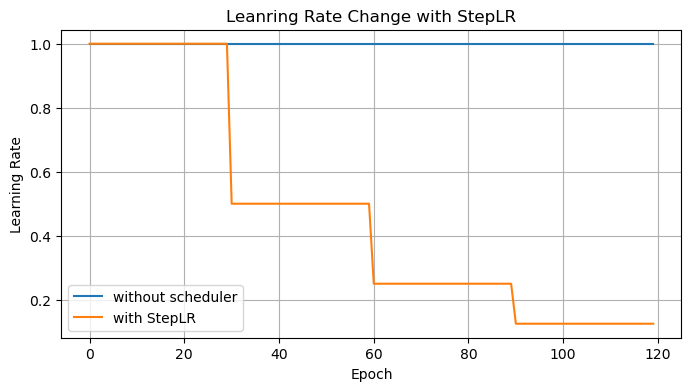

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(base_lr_history, label='without scheduler')
plt.plot(step_lr_history, label='with StepLR')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Leanring Rate Change with StepLR')
plt.legend()
plt.grid()
plt.show()

## 4. ReduceLROnPlateau

`ReduceLROnPlateau`는 validation loss 같은 지표가
한동안 좋아지지 않을 때 learning rate를 줄이는 방식이다.

주요 파라미터
- `mode='min'`: loss처럼 작을수록 좋은 값을 볼 때 사용
- `patience`: 몇 epoch 동안 개선이 없으면 줄일지
- `factor`: 줄일 비율
- `threshold`: 얼마나 좋아져야 **개선** 으로 볼지 기준
- `min_lr`: learning rate가 너무 작아지지 않도록 하한선 지정

즉 StepLR이 미리 정한 규칙이라면,
ReduceLROnPlateau는 실제 검증 지표 반응에 따라 움직이는 방식이다.

In [10]:
def train_with_plateau(initial_lr=1.0, epochs=120, patience=8, factor=0.5, threshold=1e-3, min_lr=1e-3):
    torch.manual_seed(42)

    model = BinaryMLP(hidden_size=64)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=initial_lr, momentum=0.9)

    # ReduceLROnPlateau: validation loss가 일정 기간 좋아지지 않으면 learning rate를 줄인다.
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer=optimizer,
        mode='min',                 # loss는 작을수록 좋으므로 min
        patience=patience,          # 개선이 없다고 판단하기 전 기다릴 epoch 수
        factor=factor,              # lr에 곱할 감소 비율
        threshold=threshold,        # 이정도 좋아져야 개선으로 판단
        min_lr=min_lr               # learning rate의 하한선
    )

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    lr_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        train_logits = model(X_train)
        train_loss = criterion(train_logits, y_train)

        train_loss.backward()
        optimizer.step()

        train_loss_eval, val_loss_eval, train_acc, val_acc = evaluate_binary_model(
            model, X_train, y_train, X_val, y_val
        )

        train_losses.append(train_loss_eval)
        val_losses.append(val_loss_eval)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        lr_history.append(optimizer.param_groups[0]['lr'])

        # ReduceLROnPlateau는 step에 모니터링 할 지표를 넣어야 한다
        scheduler.step(val_loss_eval)

    return train_losses, val_losses, train_accs, val_accs, lr_history

In [12]:
plateau_train_losses, plateau_val_losses, plateau_train_accs, plateau_val_accs, plateau_lr_history = train_with_plateau(
    initial_lr=1.0, epochs=120, patience=8, factor=0.5, threshold=1e-3, min_lr=1e-3
)

print(f'final val loss : {plateau_val_losses[-1]:.4f}')
print(f'final val acc : {plateau_val_accs[-1]:.4f}')
print()
print('learning rate 변화가 있었던 epoch')
for i in range(1, len(plateau_lr_history)):
    if plateau_lr_history[i] != plateau_lr_history[i - 1]:
        print(f'epoch {i+1:3d}: lr={plateau_lr_history[i]:.6f}')


final val loss : 0.0807
final val acc : 0.9750

learning rate 변화가 있었던 epoch
epoch  16: lr=0.500000
epoch  54: lr=0.250000
epoch  63: lr=0.125000
epoch  72: lr=0.062500
epoch  81: lr=0.031250
epoch  90: lr=0.015625
epoch  99: lr=0.007812
epoch 108: lr=0.003906
epoch 117: lr=0.001953


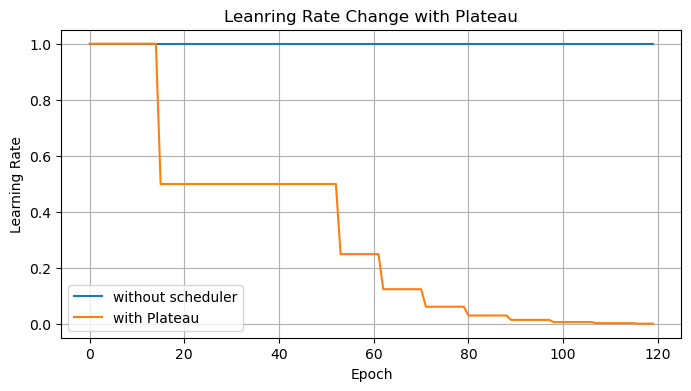

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(base_lr_history, label='without scheduler')
plt.plot(plateau_lr_history, label='with Plateau')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Leanring Rate Change with Plateau')
plt.legend()
plt.grid()
plt.show()

## 5. CosineAnnealingLR

`CosineAnnealingLR`은 learning rate를
코사인 곡선 형태로 부드럽게 줄여가는 방식이다.

주요 파라미터
- `T_max`: 한 주기 길이
- `eta_min`: 내려갈 learning rate의 최솟값

계단처럼 뚝 줄이기보다
완만하게 감소시키는 흐름을 보고 싶을 때 자주 사용한다.

In [14]:
def train_with_cosine(initial_lr=1.0, epochs=120, T_max=100, eta_min=0.001):
    torch.manual_seed(42)

    model = BinaryMLP(hidden_size=64)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=initial_lr, momentum=0.9)

    # CosineAnnealingLR: learning rate를 코사인 곡선형태로 조금씩 줄여간다.
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer=optimizer,
        T_max=T_max,            # learning rate가 한 번 내려가는 주기
        eta_min=eta_min         # 내려갈 learing rate의 최소값
    )

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    lr_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        train_logits = model(X_train)
        train_loss = criterion(train_logits, y_train)

        train_loss.backward()
        optimizer.step()

        train_loss_eval, val_loss_eval, train_acc, val_acc = evaluate_binary_model(
            model, X_train, y_train, X_val, y_val
        )

        train_losses.append(train_loss_eval)
        val_losses.append(val_loss_eval)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        lr_history.append(optimizer.param_groups[0]['lr'])

        # ConsineAnnealingLR은 보통 epoch 끝에서 step()을 호출한다.
        scheduler.step()

    return train_losses, val_losses, train_accs, val_accs, lr_history

final val loss : 0.0785
final val acc : 0.9900



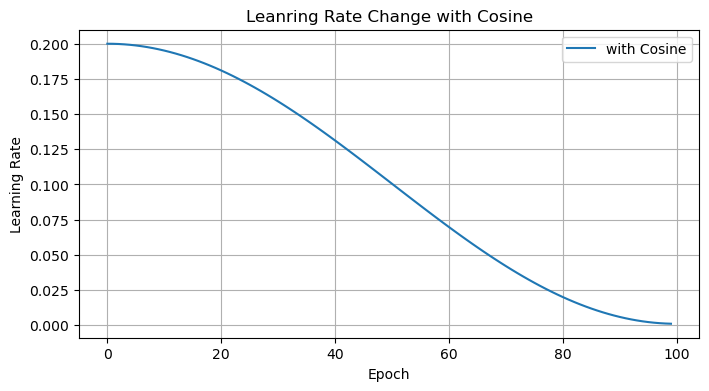

In [18]:
cos_train_losses, cos_val_losses, cos_train_accs, cos_val_accs, cos_lr_history = train_with_cosine(
    initial_lr=0.2, epochs=100, T_max=100, eta_min=0.001
)

print(f'final val loss : {cos_val_losses[-1]:.4f}')
print(f'final val acc : {cos_val_accs[-1]:.4f}')
print()

plt.figure(figsize=(8, 4))
# plt.plot(base_lr_history, label='without scheduler')
plt.plot(cos_lr_history, label='with Cosine')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Leanring Rate Change with Cosine')
plt.legend()
plt.grid()
plt.show()

## 6. OneCycleLR

`OneCycleLR`은 학습 초반에 learning rate를 올렸다가
이후에는 다시 크게 낮추는 방식이다.

주요 파라미터
- `max_lr`: 올라갔을 때의 최고 learning rate
- `epochs`: 전체 epoch 수
- `steps_per_epoch`: epoch당 optimizer step 횟수
- `pct_start`: 초반 몇 퍼센트 구간까지 learning rate를 올릴지

중요한 점은
`OneCycleLR`은 보통 batch마다 `scheduler.step()`을 호출한다는 것이다.
즉 epoch마다 한 번이 아니라 mini-batch마다 한 번씩 반영되는 방식이다.

In [19]:
from torch.utils.data import TensorDataset, DataLoader

def train_with_onecycle(initial_lr=1.0, epochs=30, max_lr=0.2, batch_size=32, pct_start=0.3):
    torch.manual_seed(42)

    model = BinaryMLP(hidden_size=64)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=initial_lr, momentum=0.9)

    # OneCycleLR: mini-batch 마다 learning rate를 바꾸는 경우가 많으므로 DataLoader를 사용해 batch 단위 학습 예제로 설정
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # OneCycleLR: 초반에는 learning rate를 올리고, 이후에는 max_lr 에서 아주 작은 값까지 길게 줄여간다.
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer=optimizer,
        max_lr=max_lr,                              # 올라갈 학습률의 최고값
        epochs=epochs,                              # 전체 epoch 수
        steps_per_epoch=len(train_loader),          # epoch 당 optimizer.step() 횟수
        pct_start=pct_start                         # 전체 step 중 초반 몇 %까지 학습률을 올릴지
    )

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    lr_history = []

    for epoch in range(epochs):
        model.train()

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            loss.backward()
            optimizer.step()

            # OneCycleLR은 보통 batch 마다 step을 호출한다.
            lr_history.append(optimizer.param_groups[0]['lr'])
            scheduler.step()

        train_loss_eval, val_loss_eval, train_acc, val_acc = evaluate_binary_model(
            model, X_train, y_train, X_val, y_val
        )

        train_losses.append(train_loss_eval)
        val_losses.append(val_loss_eval)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return train_losses, val_losses, train_accs, val_accs, lr_history

final val loss : 0.0762
final val acc : 0.9800



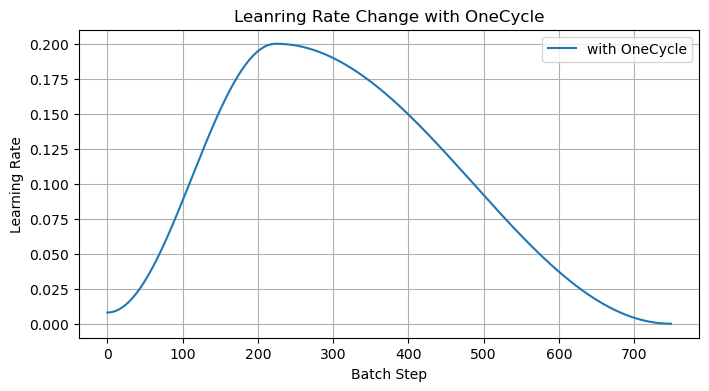

In [21]:
one_train_losses, one_val_losses, one_train_accs, one_val_accs, one_lr_history = train_with_onecycle(
    initial_lr=0.01, max_lr=0.2, epochs=30, batch_size=32, pct_start=0.3
)

print(f'final val loss : {one_val_losses[-1]:.4f}')
print(f'final val acc : {one_val_accs[-1]:.4f}')
print()

plt.figure(figsize=(8, 4))
# plt.plot(base_lr_history, label='without scheduler')
plt.plot(one_lr_history, label='with OneCycle')
plt.xlabel('Batch Step')
plt.ylabel('Learning Rate')
plt.title('Leanring Rate Change with OneCycle')
plt.legend()
plt.grid()
plt.show()

## 정리

1. scheduler는 학습 중 learning rate를 자동으로 조절하는 도구이다.
2. StepLR은 일정 epoch마다 learning rate를 줄인다.
3. ReduceLROnPlateau는 validation loss 같은 지표가 정체될 때 줄인다.
4. CosineAnnealingLR은 learning rate를 부드러운 곡선 형태로 줄인다.
5. OneCycleLR은 초반에 learning rate를 올리고 이후에는 크게 낮춘다.
6. scheduler를 이해할 때는 언제 줄이는가와 `step()`을 어디서 호출하는가를 함께 보는 것이 중요하다.